In [1]:
import pandas as pd

df = pd.read_csv('candidates.csv')
display(df.head())
df.info()

,First Name,Last Name,Email,Country,Application Date,Yoe,Seniority,Technology,Code Challenge Score,Technical Interview
0,Danielle,Levy,ashleysellers@gmail.com,UK,2024-11-23,6.0,Manager,Mulesoft,0,0.0
1,Angel,Ortega,gary31@yahoo.com,USA,2025-03-21,19.0,NaN,Mulesoft,9,6.0
2,Joshua,Lopez,austingarcia@hotmail.com,Ecuador,2024-10-12,14.0,NaN,Mulesoft,2,5.0
3,Jeffrey,Powers,courtney32@gmail.com,Colombia,2024-10-29,10.0,Lead,Java Backend,3,NaN
4,Jill,Robinson,stokessuzanne@gmail.com,Australia,2022-04-05,7.0,Junior,QA Manual,3,3.0


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   First Name            50000 non-null  str    
 1   Last Name             50000 non-null  str    
 2   Email                 47491 non-null  str    
 3   Country               50000 non-null  str    
 4   Application Date      50000 non-null  str    
 5   Yoe                   47509 non-null  float64
 6   Seniority             47489 non-null  str    
 7   Technology            50000 non-null  str    
 8   Code Challenge Score  50000 non-null  int64  
 9   Technical Interview   47494 non-null  float64
dtypes: float64(2), int64(1), str(7)
memory usage: 3.8 MB


In [7]:
#check point como buena práctica para no perder el df original
df_checkpoint = df.copy()
df_clean = df.copy()

df_clean['Technical Interview'] = df_clean['Technical Interview'].fillna(0)

df_clean['Seniority'] = df_clean['Seniority'].fillna('Unknown')

df_clean['Yoe'] = df_clean['Yoe'].fillna(0).abs()

#Correos que están mal escritos o nulos
df_clean['Email'] = df_clean['Email'].fillna('nocorreo@correo.com')
filtro_correos_malos = ~df_clean['Email'].str.contains(r'@.*\.com', regex=True)
df_clean.loc[filtro_correos_malos, 'Email'] = 'nocorreo@correo.com'

# Verificamos que los nulos hayan desaparecido
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   First Name            50000 non-null  str    
 1   Last Name             50000 non-null  str    
 2   Email                 50000 non-null  str    
 3   Country               50000 non-null  str    
 4   Application Date      50000 non-null  str    
 5   Yoe                   50000 non-null  float64
 6   Seniority             50000 non-null  str    
 7   Technology            50000 non-null  str    
 8   Code Challenge Score  50000 non-null  int64  
 9   Technical Interview   50000 non-null  float64
dtypes: float64(2), int64(1), str(7)
memory usage: 3.8 MB


In [8]:
df_business = df_clean.copy()

condicion_contratado = (df_business['Code Challenge Score'] >= 7) & (df_business['Technical Interview'] >= 7)

df_business['Hired_Score'] = condicion_contratado.astype(int)

#prueba de visualización de las columnas relevantes para la decisión de contratación
display(df_business[['First Name', 'Last Name', 'Code Challenge Score', 'Technical Interview', 'Hired_Score']].head(30))

,First Name,Last Name,Code Challenge Score,Technical Interview,Hired_Score
0,Danielle,Levy,0,0.0,0
1,Angel,Ortega,9,6.0,0
2,Joshua,Lopez,2,5.0,0
3,Jeffrey,Powers,3,0.0,0
4,Jill,Robinson,3,3.0,0
5,Erica,Vance,2,3.0,0
6,Patricia,Ramirez,2,0.0,0
7,Christopher,Baird,6,6.0,0
8,Robert,Lee,7,3.0,0
9,Anthony,Parsons,9,9.0,1


In [9]:
df_business = df_clean.copy()

#regla de negocio
condicion_contratado = (df_business['Code Challenge Score'] >= 7) & (df_business['Technical Interview'] >= 7)
df_business['Hired_Score'] = condicion_contratado.astype(int)

df_business['Application Date'] = pd.to_datetime(df_business['Application Date'])
dm_tiempo = df_business[['Application Date']].drop_duplicates().reset_index(drop=True)
dm_tiempo['ID_date'] = dm_tiempo.index + 1
dm_tiempo['year'] = dm_tiempo['Application Date'].dt.year
dm_tiempo['month'] = dm_tiempo['Application Date'].dt.month

dm_lugar = df_business[['Country']].drop_duplicates().reset_index(drop=True)
dm_lugar['ID_lugar'] = dm_lugar.index + 1

dm_candidatos = df_business[['First Name', 'Last Name', 'Email']].drop_duplicates().reset_index(drop=True)
dm_candidatos['ID_candidato'] = dm_candidatos.index + 1

dm_laboral_experiences = df_business[['Seniority', 'Technology', 'Yoe']].drop_duplicates().reset_index(drop=True)
dm_laboral_experiences['ID_laboralxp'] = dm_laboral_experiences.index + 1

fact_df = df_business.merge(dm_tiempo, on='Application Date')
fact_df = fact_df.merge(dm_lugar, on='Country')
fact_df = fact_df.merge(dm_candidatos, on=['First Name', 'Last Name', 'Email'])
fact_df = fact_df.merge(dm_laboral_experiences, on=['Seniority', 'Technology', 'Yoe'])

Fact_Hired_process = fact_df[['ID_candidato', 'ID_date', 'ID_lugar', 'ID_laboralxp', 
                             'Code Challenge Score', 'Technical Interview', 'Hired_Score']]

print("¡ok proceso de transformación")
display(Fact_Hired_process.head())

¡ok proceso de transformación


,ID_candidato,ID_date,ID_lugar,ID_laboralxp,Code Challenge Score,Technical Interview,Hired_Score
0,1,1,1,1,0,0.0,0
1,2,2,2,2,9,6.0,0
2,3,3,3,3,2,5.0,0
3,4,4,4,4,3,0.0,0
4,5,5,5,5,3,3.0,0


In [10]:
import sqlite3

conexion = sqlite3.connect('contrataciones_dw.db')

dm_tiempo.to_sql('dm_tiempo', conexion, if_exists='replace', index=False)
dm_lugar.to_sql('dm_lugar', conexion, if_exists='replace', index=False)
dm_candidatos.to_sql('dm_candidatos', conexion, if_exists='replace', index=False)
dm_laboral_experiences.to_sql('dm_laboral_experiences', conexion, if_exists='replace', index=False)
Fact_Hired_process.to_sql('Fact_Hired_process', conexion, if_exists='replace', index=False)

conexion.close()

print("Proceso de Carga exitosamente en contrataciones_dw.db")

Proceso de Carga exitosamente en contrataciones_dw.db


In [11]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 5.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 6.4 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 7.4 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.5 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 8.1 MB/s  0:00:01
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 13.6 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------------- ---------------------- 3.1/7.2 MB 15.4 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\valeg\AppData\Local\Temp\ipykernel_9908\1428014331.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_b, x='Total_Hires', y=df_b['year'].astype(str), ax=axes[0, 1], palette='Blues_r')
C:\Users\valeg\AppData\Local\Temp\ipykernel_9908\1428014331.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_c, x='Seniority', y='Total_Hires', ax=axes[1, 0], palette='Set2')


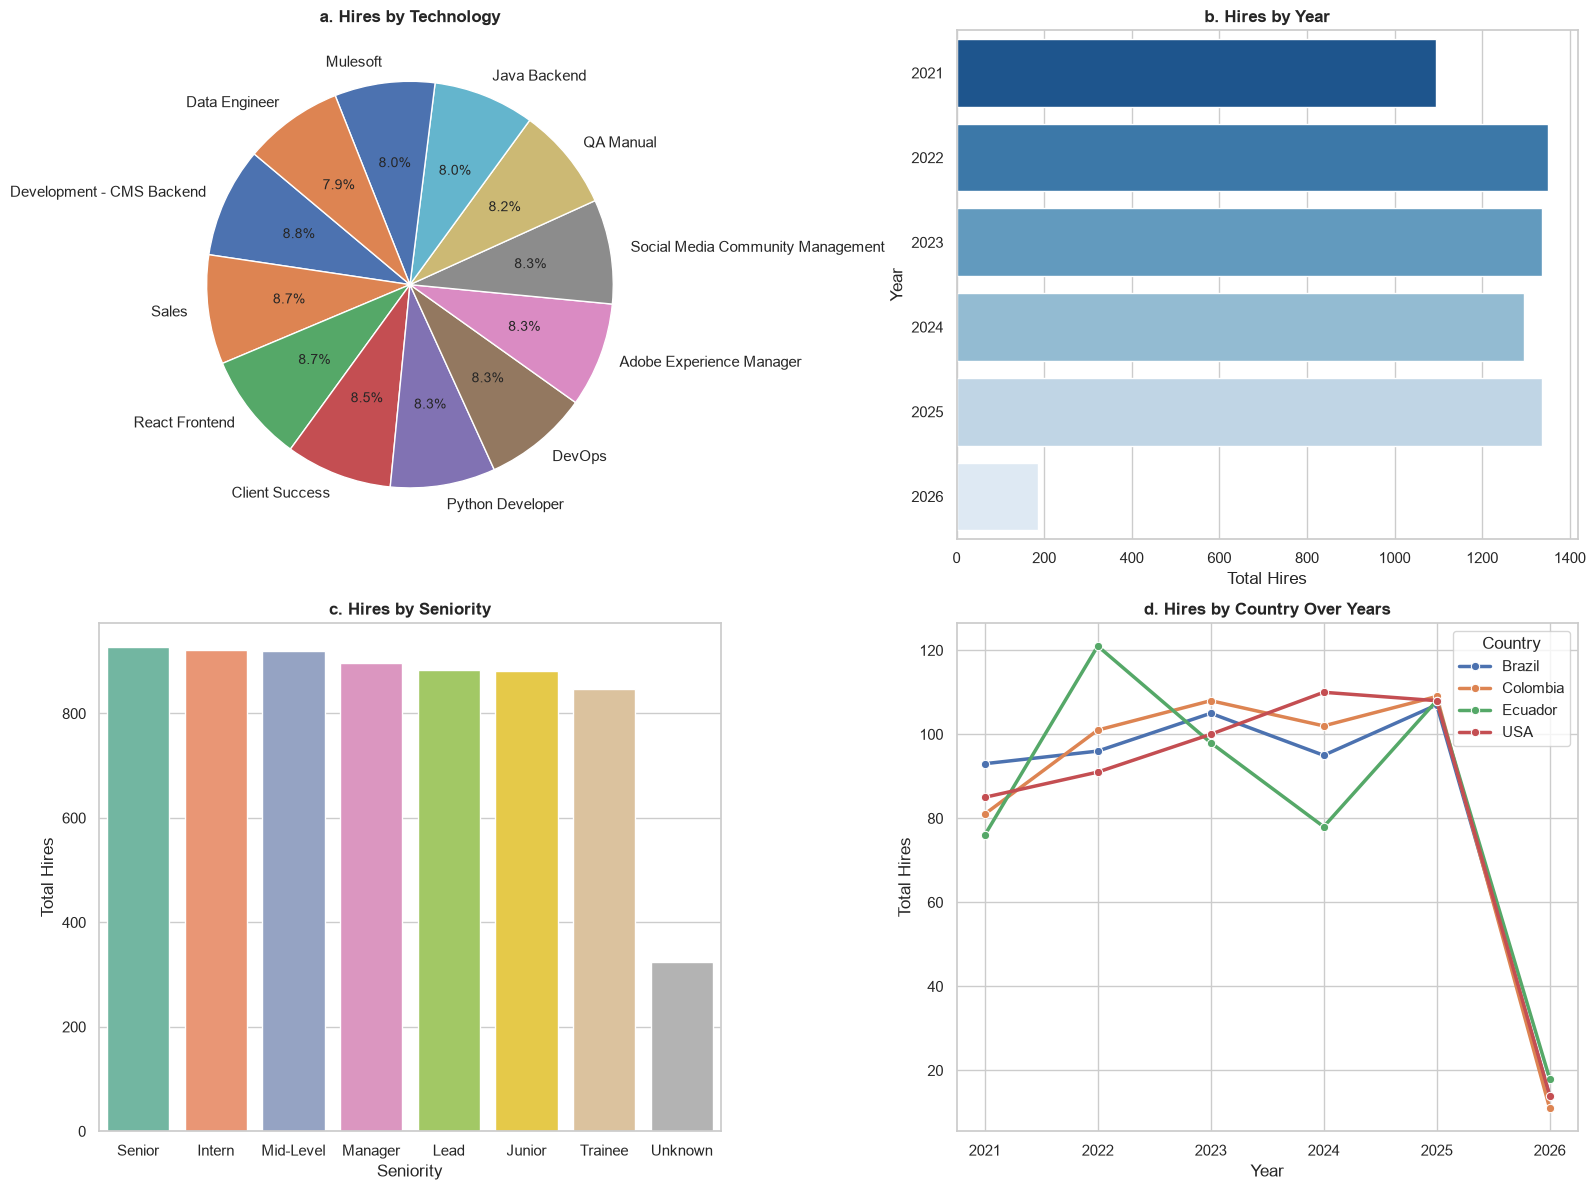

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

#conexión con el DW
conexion = sqlite3.connect('contrataciones_dw.db')

# Gráfica A
query_a = """
SELECT e.Technology, COUNT(*) as Total_Hires
FROM Fact_Hired_process f
JOIN dm_laboral_experiences e ON f.ID_laboralxp = e.ID_laboralxp
WHERE f.Hired_Score = 1
GROUP BY e.Technology
ORDER BY Total_Hires DESC
"""
df_a = pd.read_sql_query(query_a, conexion)

# Gráfica B
query_b = """
SELECT t.year, COUNT(*) as Total_Hires
FROM Fact_Hired_process f
JOIN dm_tiempo t ON f.ID_date = t.ID_date
WHERE f.Hired_Score = 1
GROUP BY t.year
ORDER BY t.year ASC
"""
df_b = pd.read_sql_query(query_b, conexion)

# Gráfica C
query_c = """
SELECT e.Seniority, COUNT(*) as Total_Hires
FROM Fact_Hired_process f
JOIN dm_laboral_experiences e ON f.ID_laboralxp = e.ID_laboralxp
WHERE f.Hired_Score = 1
GROUP BY e.Seniority
ORDER BY Total_Hires DESC
"""
df_c = pd.read_sql_query(query_c, conexion)

# Gráfica D
query_d = """
SELECT l.Country, t.year, COUNT(*) as Total_Hires
FROM Fact_Hired_process f
JOIN dm_lugar l ON f.ID_lugar = l.ID_lugar
JOIN dm_tiempo t ON f.ID_date = t.ID_date
WHERE f.Hired_Score = 1 
  AND l.Country IN ('USA', 'Brazil', 'Brasil', 'Colombia', 'Ecuador')
GROUP BY l.Country, t.year
ORDER BY t.year, l.Country
"""
df_d = pd.read_sql_query(query_d, conexion)

conexion.close()


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#A
axes[0, 0].pie(df_a['Total_Hires'], labels=df_a['Technology'], autopct='%1.1f%%', startangle=140)
axes[0, 0].set_title('a. Hires by Technology', fontsize=12, fontweight='bold')

#B
sns.barplot(data=df_b, x='Total_Hires', y=df_b['year'].astype(str), ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('b. Hires by Year', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Hires')
axes[0, 1].set_ylabel('Year')

#C
sns.barplot(data=df_c, x='Seniority', y='Total_Hires', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('c. Hires by Seniority', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Total Hires')

#D
sns.lineplot(data=df_d, x='year', y='Total_Hires', hue='Country', marker='o', ax=axes[1, 1], linewidth=2.5)
axes[1, 1].set_title('d. Hires by Country Over Years', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Total Hires')
axes[1, 1].set_xlabel('Year')

plt.tight_layout()
plt.show()